In [2]:
import os                                   #imported warnings as to hide any unncecessary warnings arising during the program
import warnings
warnings.filterwarnings('ignore')

import numpy as np                         #imported libraries and tools for data statistics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import yfinance as yf
import statsmodels.api as sm                         # to run OLS regression and statistical tests
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA      # from ARIMA models

try:
    from pmdarima import auto_arima  #this block tries to import auto arima form pmdarima , if import works then have section otherwise 
    HAVE_PMDARIMA= True
except Exception:
    HAVE_PMDARIMA=False

OUTPUT_DIR= "results"                         # setting up output folders where all my graphs , tables and outputs will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)

PAPER_PATH=  "/mnt/data/Individual_Assignment_FIN41660 2025 (1).pdf"
SP500_TICKER= "^GSPC"                                                 #defining tickers and dates                #CL=F means crude light futures contract





In [3]:
#pip install spotipy

import spotipy  #import spotify API library and a way to authenticate using client credentials
from spotipy.oauth2 import SpotifyClientCredentials

sp_df= pd.read_csv("spotify_sentiment.csv", parse_dates=["date"]) #read csv file into dataframe called sp_df
print("loaded spotify rows:", len(sp_df))                         #parse_dates tell pandas to treat date column as real datetime and not just string
display(sp_df.head())                                             
#shows first 5 rows so you can visually check the data.

daily_sentiment = sp_df.groupby('date').agg(                 #group all rows by each date, compute summary stats for each date
    avg_valence=('valence','mean'),                        #for each date average the valence of track
    avg_energy=('energy','mean'),                          #for each date, average the energy
    total_streams=('streams','sum')).sort_index()         #for each date sum all streams for all songs
daily_sentiment.head()                                    



loaded spotify rows: 18250


,date,track_id,track_name,artist,streams,valence,energy,tempo
0,2023-01-01,track_1,Song track_1,Artist 18,50790,0.539409,0.374173,170.771602
1,2023-01-01,track_2,Song track_2,Artist 2,154939,0.280904,0.776509,173.581650
2,2023-01-01,track_3,Song track_3,Artist 17,353456,0.757914,0.337165,115.371503
3,2023-01-01,track_4,Song track_4,Artist 7,276104,0.800787,0.571801,107.253266
4,2023-01-01,track_5,Song track_5,Artist 11,450822,0.337826,0.241498,129.208756


,avg_valence,avg_energy,total_streams
date,,,
2023-01-01,0.518366,0.569122,13964479
2023-01-02,0.485018,0.535122,12168690
2023-01-03,0.475124,0.539957,13804648
2023-01-04,0.533326,0.558499,14098595
2023-01-05,0.498080,0.521762,12936344


In [4]:
sp500=yf.download("^GSPC",start="2023-01-01",end="2023-12-31",auto_adjust=True)  #auto_adjust adjusts foor splits/dividends
sp500=sp500["Close"]  #take closing prices of the stock

#business day frequency
sp500_b=sp500.asfreq("B").fillna(method='ffill')  #reindex the price series to business days(mon-fri), if a day has no value(eg weekend, holiday it becomes NaN for now
                                                  # forward- fill missing values, so weekends and holidays simply repeat prior tradng day's price
#log returns
sp500_ret=np.log(sp500_b).diff().dropna()  #take natural log of price, subtract the previous day's log price , removes first row because it gives NaN
sp500_ret.name= "SP500_logret" 

sp500_ret.head()

sp500_ret.to_csv(os.path.join(OUTPUT_DIR,'sp500_logret.csv')) 
print("SP return sample")
display(sp500_ret.head())

[*********************100%***********************]  1 of 1 completed

SP return sample


Ticker,^GSPC
Date,
2023-01-04,0.007511
2023-01-05,-0.011714
2023-01-06,0.022584
2023-01-09,-0.000768
2023-01-10,0.006954


In [5]:
#convert sentiment to business days
sentiment_b= daily_sentiment['avg_valence'].asfreq('B').fillna(method='ffill')
df=pd.concat([sp500_ret, sentiment_b],axis=1).dropna() #combine S&P returns and sentiments into same DataFrame side by side, matching on dates(index)
df.columns=["SP500_logret","avg_valence"]
print("merged sample size:",len(df))
display(df.head())



merged sample size: 258


,SP500_logret,avg_valence
2023-01-04,0.007511,0.533326
2023-01-05,-0.011714,0.498080
2023-01-06,0.022584,0.467926
2023-01-09,-0.000768,0.541051
2023-01-10,0.006954,0.507092


In [6]:

desc=df.describe().T
desc.to_csv(os.path.join(OUTPUT_DIR,'descriptive_stats.csv'))
print(desc)

              count      mean       std       min       25%       50%  \
SP500_logret  258.0  0.000857  0.008108 -0.020245 -0.003898  0.000524   
avg_valence   258.0  0.498808  0.039970  0.358718  0.474315  0.500572   

                   75%       max  
SP500_logret  0.006096  0.022584  
avg_valence   0.528481  0.598690  


In [7]:
Y=df['SP500_logret']  #this is my dependent variable
X=sm.add_constant(df['avg_valence']) #independent variable(explanatory)= daily average music mood score

ols= sm.OLS(Y,X).fit(cov_type='HC1') #adds a column of ones called const so the regression includes interecept
print("OLS (same-day) summary:")   #HC1 actually estimates the model and tell it to use heteroskedasticity -robust   standard errors
print(ols.summary())

OLS (same-day) summary:
                            OLS Regression Results                            
Dep. Variable:           SP500_logret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.2826
Date:                Sun, 14 Dec 2025   Prob (F-statistic):              0.595
Time:                        18:04:09   Log-Likelihood:                 876.78
No. Observations:                 258   AIC:                            -1750.
Df Residuals:                     256   BIC:                            -1742.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0039    

In [8]:
#Lag-1 regression (yesterday's music->today's returns)-often more sensible
df["Valence_lag1"]=df["avg_valence"].shift(1)
df_lag=df.dropna()
Y_lag=df_lag["SP500_logret"]
X_lag=sm.add_constant(df_lag["Valence_lag1"])
ols_lag=sm.OLS(Y_lag,X_lag).fit(cov_type="HC1")
print("OLS (lag-1) summary:")
print(ols_lag.summary())

OLS (lag-1) summary:
                            OLS Regression Results                            
Dep. Variable:           SP500_logret   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.5820
Date:                Sun, 14 Dec 2025   Prob (F-statistic):              0.446
Time:                        18:04:09   Log-Likelihood:                 873.38
No. Observations:                 257   AIC:                            -1743.
Df Residuals:                     255   BIC:                            -1736.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0055    

In [9]:
# Newey-West (HAC) SEs and comparison 
nlags = 10   # choose 10 for daily data; change to ~4 if using weekly data

ols_lag_hac = ols_lag.get_robustcov_results(cov_type='HAC', maxlags=nlags)

print("=== Coefficient table (HC1 vs Newey-West HAC, nlags={}) ===".format(nlags))
comp = pd.DataFrame({
    'coef': ols_lag.params,
    'se_HC1': ols_lag.bse,
    'se_HAC': ols_lag_hac.bse,
    't_HAC': ols_lag_hac.tvalues,
    'p_HAC': ols_lag_hac.pvalues
})
display(comp.loc[comp.index.isin(['const','Valence_lag1'])])   # show the main rows
comp.to_csv(os.path.join(OUTPUT_DIR,'coef_se_comparison_lag1.csv'))
print("Saved comparison to:", os.path.join(OUTPUT_DIR,'coef_se_comparison_lag1.csv'))


=== Coefficient table (HC1 vs Newey-West HAC, nlags=10) ===


,coef,se_HC1,se_HAC,t_HAC,p_HAC
const,0.005491,0.006191,0.005477,1.002503,0.316101
Valence_lag1,-0.009339,0.012242,0.010565,-0.883989,0.376702


Saved comparison to: results\coef_se_comparison_lag1.csv


In [10]:
# AR(1) model: include lagged dependent variable and run HAC
# create lagged dependent variable and align rows
df['SP500_logret_lag1'] = df['SP500_logret'].shift(1)
df_ar = df.dropna(subset=['SP500_logret_lag1','Valence_lag1'])

Y_ar = df_ar['SP500_logret']
X_ar = df_ar[['Valence_lag1','SP500_logret_lag1']]   # add more controls later if desired
X_ar = sm.add_constant(X_ar)

# Fit OLS then HAC
model_ar = sm.OLS(Y_ar, X_ar).fit()
model_ar_hac = model_ar.get_robustcov_results(cov_type='HAC', maxlags=nlags)

print("AR(1) model (usual SE):")
print(model_ar.summary().tables[1])
print("\nAR(1) model (Newey-West HAC):")
print(model_ar_hac.summary().tables[1])

pd.DataFrame({
    'coef': model_ar.params,
    'se_HC1': model_ar.bse,
    'se_HAC': model_ar_hac.bse,
    'p_HAC': model_ar_hac.pvalues
}).to_csv(os.path.join(OUTPUT_DIR,'ar1_coef_comparison.csv'))
print("Saved AR(1) coef comparison to:", os.path.join(OUTPUT_DIR,'ar1_coef_comparison.csv'))


AR(1) model (usual SE):
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0054      0.006      0.844      0.399      -0.007       0.018
Valence_lag1         -0.0092      0.013     -0.720      0.472      -0.034       0.016
SP500_logret_lag1     0.0250      0.063      0.400      0.690      -0.098       0.148

AR(1) model (Newey-West HAC):
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0054      0.005      1.001      0.318      -0.005       0.016
Valence_lag1         -0.0092      0.010     -0.883      0.378      -0.030       0.011
SP500_logret_lag1     0.0250      0.057      0.436      0.663      -0.088       0.138
Saved AR(1) coef comparison to: results\ar1_coef_comparison.csv


In [11]:
#simple bootstrap CI for Valence_lag1 (n=1000)
np.random.seed(123)
nboot = 1000
coef_boot = []
for i in range(nboot):
    boot = df_lag.sample(frac=1, replace=True)
    resb = sm.OLS(boot['SP500_logret'], sm.add_constant(boot['Valence_lag1'])).fit()
    coef_boot.append(resb.params['Valence_lag1'])
ci_low, ci_high = np.percentile(coef_boot, [2.5, 97.5])
print("Bootstrap 95% CI for Valence_lag1:", ci_low, ci_high)
pd.Series(coef_boot).to_csv(os.path.join(OUTPUT_DIR,'bootstrap_valence_coef.csv'), index=False)


Bootstrap 95% CI for Valence_lag1: -0.03437503562271009 0.014593125218539359


In [12]:
# VIF check for X_ar (only after you add extra controls)
from statsmodels.tools.tools import add_constant
X_for_vif = X_ar.copy().drop(columns=['const'], errors='ignore')
X_for_vif = add_constant(X_for_vif)
vif_data = pd.DataFrame({
    "variable": X_for_vif.columns,
    "VIF": [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]
})
display(vif_data)
vif_data.to_csv(os.path.join(OUTPUT_DIR,'vif_ar1.csv'), index=False)
print("Saved VIF to:", os.path.join(OUTPUT_DIR,'vif_ar1.csv'))


,variable,VIF
0,const,158.196666
1,Valence_lag1,1.001062
2,SP500_logret_lag1,1.001062


Saved VIF to: results\vif_ar1.csv


In [13]:
pd.DataFrame({"coef":ols_lag.params,"std_err":ols_lag.bse,"pval":ols_lag.pvalues}).to_csv(os.path.join(OUTPUT_DIR,"ols_lag1_coefs.csv"))

# Diagnostics on the lagged model residuals
model=ols_lag
resid=model.resid

#jarque bera (normality)
jb_stat,jb_pvalue,skew,kurtosis= jarque_bera(resid)
print("Jarque bera p-value", jb_pvalue)

#Durbin watson
from statsmodels.stats.stattools import durbin_watson
dw= durbin_watson(resid)
print("Durbin_watson:", dw)

#Breusch-godfrey (serial correlation)
bg_stat,bg_pvalue,_,_= acorr_breusch_godfrey(model,nlags=4, store=False)
print("Breusch-godfrey p-value(4 lags): ", bg_pvalue)

#Breusch-Pagan (heteroskedasticity)
bp_test= het_breuschpagan(resid, model.model.exog)
print("Breusch-pagan p-value:", bp_test[1])

#Stationarity ADF
print("ADF SP500_logret p:", adfuller(df_lag["SP500_logret"])[1])
print("ADF Valence p:",adfuller(df_lag["Valence_lag1"])[1])


Jarque bera p-value 0.8934011882662678
Durbin_watson: 1.9316272044671632
Breusch-godfrey p-value(4 lags):  0.9344483186050735
Breusch-pagan p-value: 0.17190422100423908
ADF SP500_logret p: 2.3603510414311982e-28
ADF Valence p: 4.7097018706450374e-29


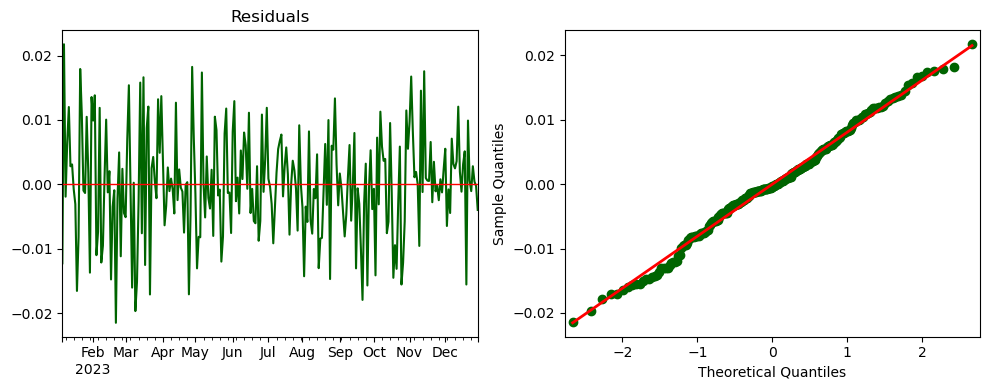

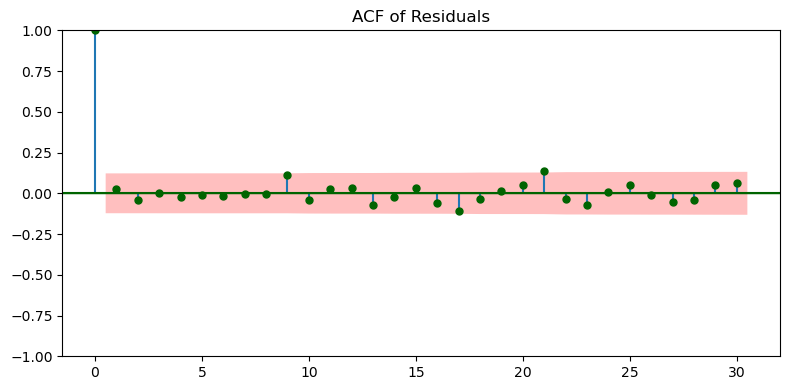

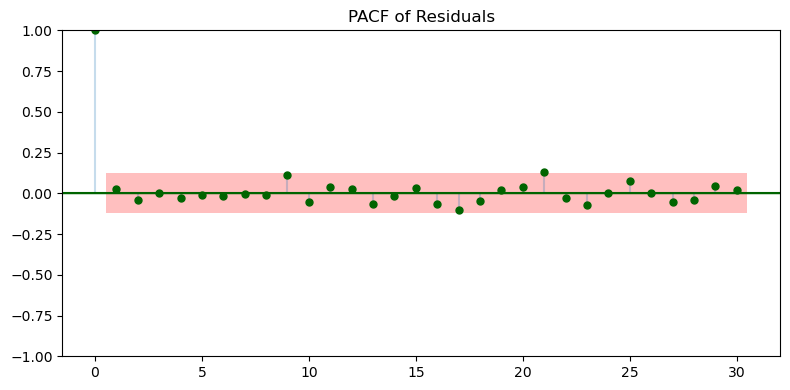

In [83]:
#Residuals plots, ACF/PACF
import matplotlib.pyplot as plt
import statsmodels.api as smm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

MAROON = 'red'      # maroonish dark pink
DARKGREEN = 'darkgreen'

-
plt.figure(figsize=(10,4))

# Residual time series
plt.subplot(1,2,1)
resid.plot(color=DARKGREEN, title="Residuals")
plt.axhline(0, color=MAROON, linewidth=1)

# QQ plot
plt.subplot(1,2,2)
fig = smm.qqplot(resid, line='s', ax=plt.gca())

ax = plt.gca()

# Recolor scatter points 
ax.lines[0].set_color(DARKGREEN)
ax.lines[0].set_markerfacecolor(DARKGREEN)
ax.lines[0].set_markeredgecolor(DARKGREEN)

# Recolor theoretical line
ax.lines[1].set_color('red')
ax.lines[1].set_linewidth(2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residuals_qq.png"), dpi=150)
plt.show()

#ACF Plot
fig, ax = plt.subplots(figsize=(8,4))
plot_acf(resid, lags=30, ax=ax)

# Recolor stems and markers
for line in ax.lines:
    line.set_color(DARKGREEN)

# Recolor confidence interval band
for patch in ax.collections:
    patch.set_facecolor(MAROON)

# Zero line
ax.axhline(0, color=DARKGREEN, linewidth=1)

plt.title("ACF of Residuals")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resid_acf.png"), dpi=150)
plt.show()


# PACF plot

fig, ax = plt.subplots(figsize=(8,4))
plot_pacf(resid, lags=30, method='ywm', ax=ax)

# Recolor stems and markers
for line in ax.lines:
    line.set_color(DARKGREEN)

# Recolor confidence interval band
for patch in ax.collections:
    patch.set_facecolor(MAROON)
    patch.set_alpha(0.25)

# Zero line
ax.axhline(0, color=DARKGREEN, linewidth=1)

plt.title("PACF of Residuals")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resid_pacf.png"), dpi=150)
plt.show()



Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1737.439, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1744.756, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1742.978, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1742.908, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1741.388, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-1742.756, Time=0.10 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.665 seconds
Using ARIMA order: (0, 0, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  257
Model:                          ARIMA   Log Likelihood                 873.378
Date:                Sun, 14 Dec 2025   AIC                          -1742.756
Time:                        18:21:28   BIC                          -1735.658
Sample:                    01-05-2023   HQIC          

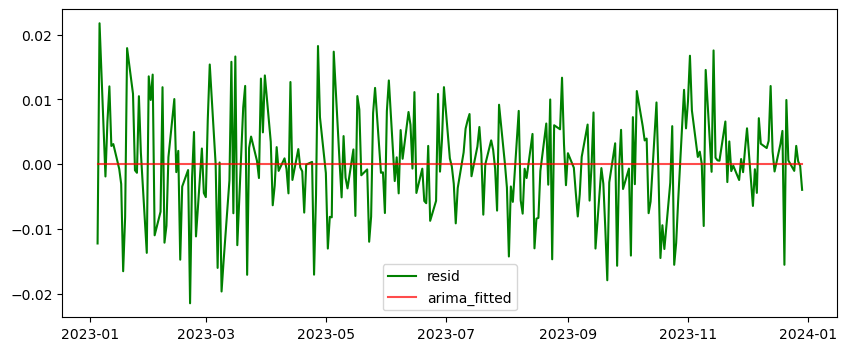

In [59]:
#9) ARIMA on residuals 
resid_series=resid.dropna()
if HAVE_PMDARIMA:
    from pmdarima import auto_arima
    arima_model=auto_arima(resid_series,seasonal=False,trace=True,error_action="ignore")
    order=arima_model.order
else:
    order=(1,0,1) 

print("Using ARIMA order:",order)
arima_res=ARIMA(resid_series,order=order).fit()
print(arima_res.summary())

plt.figure(figsize=(10,4))
plt.plot(resid_series,label='resid',color='green')
plt.plot(arima_res.fittedvalues,label="arima_fitted",alpha=0.7,color='red')
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR,"arima_fit.png"),dpi=150)
plt.show()

In [16]:
#10) short report summary
pd.Series({"sample_start":str(df.index.min().date()),
           "sample_end":str(df.index.max().date()),
           "n_obs":len(df),
           "ols_lag1_beta": float(ols_lag.params.get("valence_lag1:",np.nan)),
           "ols_lag1_p": float(ols_lag.pvalues.get("Valence_lag1",np.nan)),
           "ARIMA_order_resid":str(order)}).to_csv(os.path.join(OUTPUT_DIR,"short_summary.csv"))

print("All outputs saved to:",OUTPUT_DIR)
print("Assignment PDF path (local):", PAPER_PATH)

All outputs saved to: results
Assignment PDF path (local): /mnt/data/Individual_Assignment_FIN41660 2025 (1).pdf


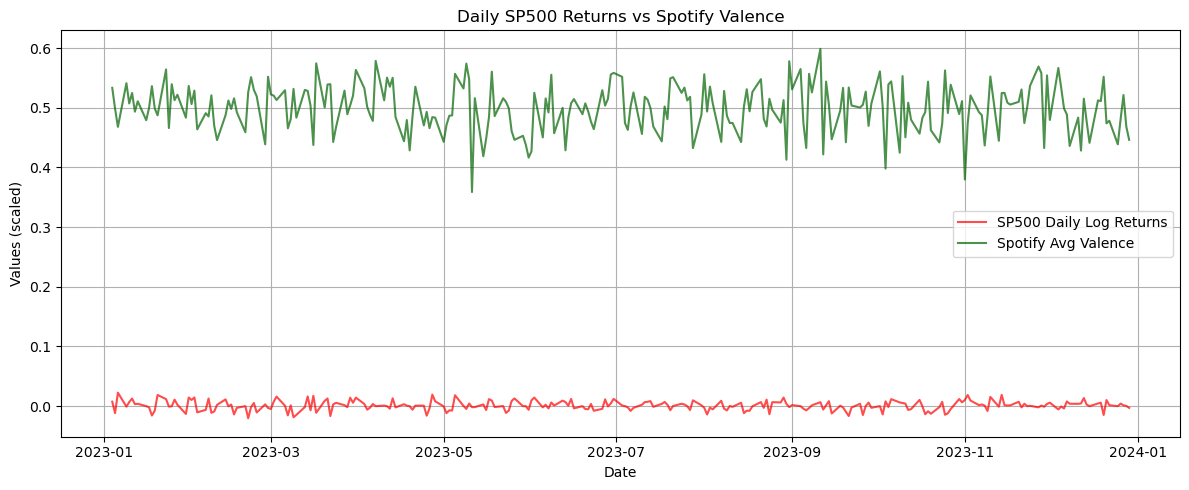

In [45]:
# Compare S&P returns and valence in one plot
plt.figure(figsize=(12,5))
plt.plot(df.index, df['SP500_logret'], label='SP500 Daily Log Returns', alpha=0.7, color='red')
plt.plot(df.index, df['avg_valence'], label='Spotify Avg Valence', alpha=0.7, color='Darkgreen')
plt.title('Daily SP500 Returns vs Spotify Valence')
plt.legend()
plt.ylabel('Values (scaled)')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"timeseries_overlay.png"))
plt.show()


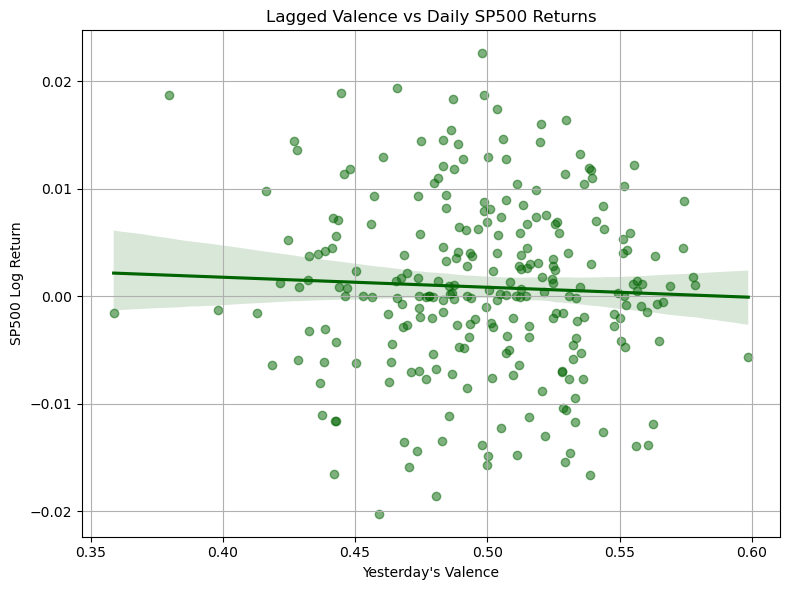

In [46]:
# scatter plot with regression line
plt.figure(figsize=(8,6))
sns.regplot(x='Valence_lag1', y='SP500_logret', data=df, scatter_kws={'alpha':0.5},color='Darkgreen')
plt.title('Lagged Valence vs Daily SP500 Returns')
plt.xlabel("Yesterday's Valence")
plt.ylabel("SP500 Log Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"scatter_regression.png"))
plt.show()


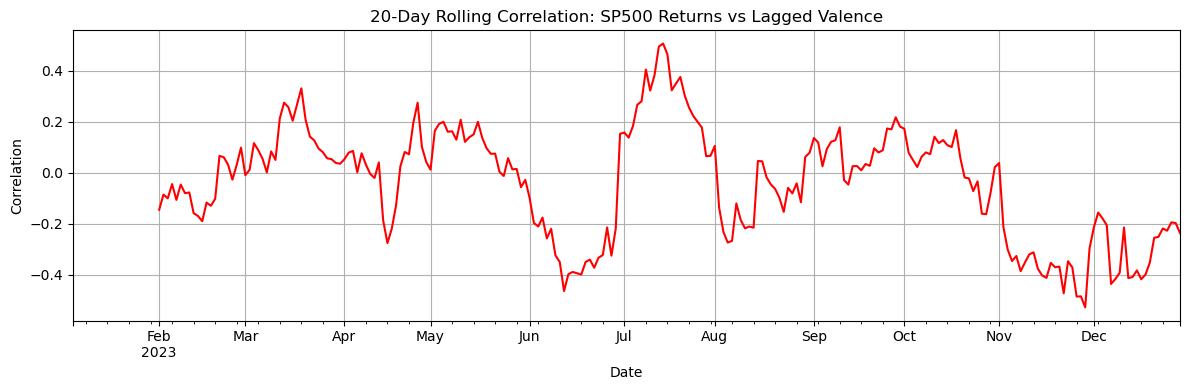

In [64]:
# How correlation changes over time 
df['rolling_corr'] = df['SP500_logret'].rolling(20).corr(df['Valence_lag1'])
plt.figure(figsize=(12,4))
df['rolling_corr'].plot(color='red')
plt.title('20-Day Rolling Correlation: SP500 Returns vs Lagged Valence')
plt.ylabel('Correlation')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"rolling_corr.png"))
plt.show()


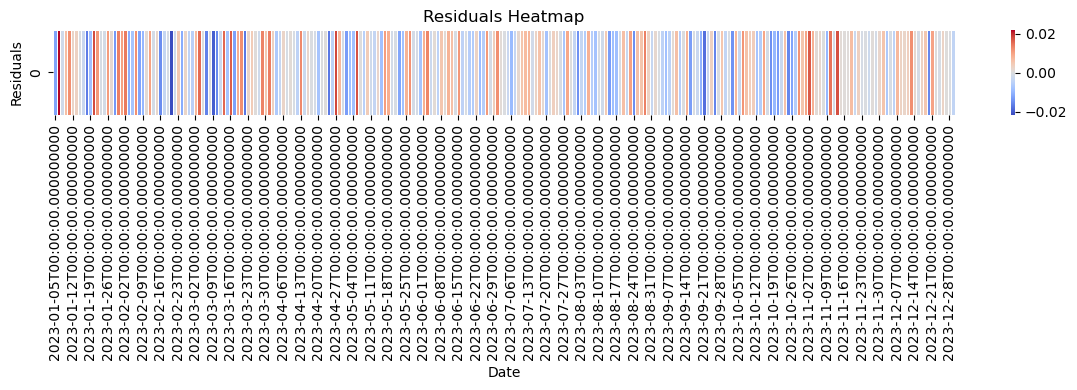

In [20]:
# residual heatmap 
plt.figure(figsize=(12,4))
sns.heatmap(resid.to_frame().T, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Residuals Heatmap')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"residuals_heatmap.png"))
plt.show()


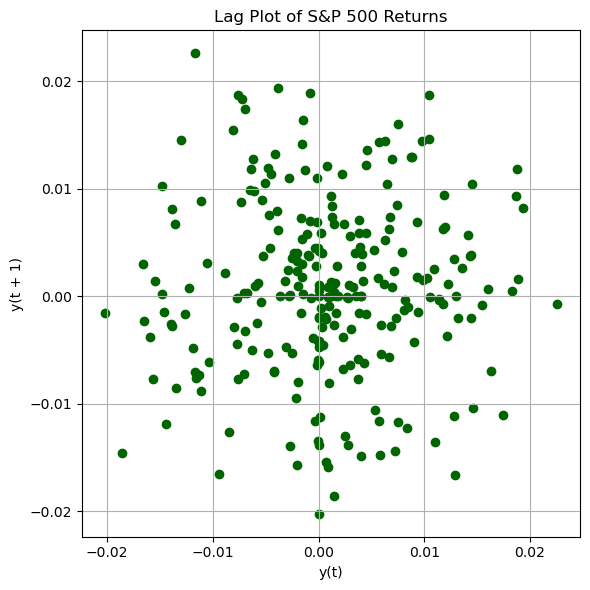

In [84]:

# Lag plot (visual autocorrelation check)
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
import os

DARKGREEN = 'darkgreen'

fig, ax = plt.subplots(figsize=(6,6))

lag_plot(df['SP500_logret'], ax=ax)
for coll in ax.collections:
    coll.set_facecolor(DARKGREEN)
    coll.set_edgecolor(DARKGREEN)

ax.set_title('Lag Plot of S&P 500 Returns')
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lag_plot.png"), dpi=150)
plt.show()


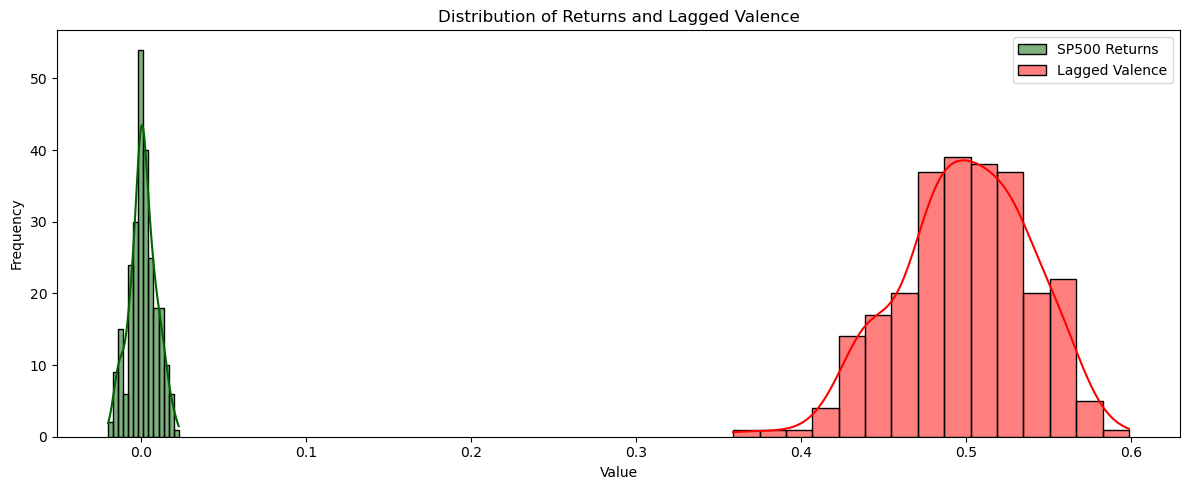

In [60]:
#Sgows distributions of returns and valence
plt.figure(figsize=(12,5))
sns.histplot(df['SP500_logret'], kde=True, color='darkgreen', label='SP500 Returns', alpha=0.5)
sns.histplot(df['Valence_lag1'], kde=True, color='red', label='Lagged Valence', alpha=0.5)
plt.title('Distribution of Returns and Lagged Valence')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"distribution_plot.png"))
plt.show()
